# Requirement 4 — FTPL full-feedback vs C-UCB Sliding Window / Change Detector



In [49]:
import itertools
from collections import deque
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import linprog
from scipy.special import betainc

## 1. Problem definition and feasible actions


In [50]:
@dataclass
class ProblemConfig:
    T: int
    N: int
    bid_grid: np.ndarray
    values: np.ndarray
    budget: float
    conflict_edges: list[tuple[int, int]]
    max_bid: float = 1.0

    @property
    def rho(self) -> float:
        return self.budget / self.T


def is_action_feasible_with_conflicts(action: np.ndarray, conflict_edges) -> bool:
    for i, j in conflict_edges:
        if action[i] > 0 and action[j] > 0:
            return False
    return True


def enumerate_conflict_feasible_actions(
    bid_grid: np.ndarray,
    N: int,
    conflict_edges=None,
) -> tuple[np.ndarray, np.ndarray]:
    actions = []
    action_indices = []

    for indices in itertools.product(range(len(bid_grid)), repeat=N):
        action = np.array([bid_grid[k] for k in indices], dtype=float)
        if is_action_feasible_with_conflicts(action, conflict_edges):
            actions.append(action)
            action_indices.append(indices)

    return np.array(actions, dtype=float), np.array(action_indices, dtype=int)


def get_zero_action_id(actions: np.ndarray) -> int:
    return int(np.where(np.isclose(actions.sum(axis=1), 0.0))[0][0])

## 2. Outcomes and feedback


In [51]:
def realized_reward_cost_all(
    actions: np.ndarray,
    m_t: np.ndarray,
    values: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    """Full vector of rewards/costs for all feasible actions."""
    wins = (actions > 0) & (actions >= m_t[None, :])
    costs = (actions * wins).sum(axis=1)
    rewards = ((values[None, :] - actions) * wins).sum(axis=1)
    return rewards, costs


def realized_per_campaign(
    action: np.ndarray,
    m_t: np.ndarray,
    values: np.ndarray,
) -> tuple[float, float, np.ndarray, np.ndarray, np.ndarray]:
    """Semi-bandit feedback for the selected action only."""
    wins = (action > 0) & (action >= m_t)
    rewards_per_campaign = np.where(wins, values - action, 0.0)
    costs_per_campaign = np.where(wins, action, 0.0)
    return (
        float(rewards_per_campaign.sum()),
        float(costs_per_campaign.sum()),
        wins,
        rewards_per_campaign,
        costs_per_campaign,
    )


def expected_reward_cost_all(
    actions: np.ndarray,
    values: np.ndarray,
    alpha: np.ndarray,
    beta: np.ndarray,
    max_bid: float = 1.0,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Expected reward/cost for every action in a Beta phase.
    If m_i = max_bid * Beta(alpha_i, beta_i), then
    P(win with bid b_i) = P(m_i <= b_i).
    """
    x = np.clip(actions / max_bid, 0.0, 1.0)
    win_probs = betainc(alpha[None, :], beta[None, :], x)
    win_probs = np.where(actions > 0, win_probs, 0.0)

    expected_costs = (actions * win_probs).sum(axis=1)
    expected_rewards = ((values[None, :] - actions) * win_probs).sum(axis=1)
    return expected_rewards, expected_costs

## 3. Slightly non-stationary Beta environment


In [52]:
@dataclass
class BetaPhase:
    start: int
    end: int
    alpha: np.ndarray
    beta: np.ndarray

    @property
    def length(self) -> int:
        return self.end - self.start


class BetaPhaseEnvironment:
    """
    Pre-samples the full sequence of highest competing bids.
    The same realized sequence is used for all algorithms for a given run seed.
    """
    def __init__(self, config: ProblemConfig, phases: list[BetaPhase], seed: int):
        self.config = config
        self.phases = phases
        self.rng = np.random.default_rng(seed)

        self.phase_ids = np.empty(config.T, dtype=int)
        self.competing_bids = np.empty((config.T, config.N), dtype=float)

        for phase_id, phase in enumerate(phases):
            sl = slice(phase.start, phase.end)
            self.phase_ids[sl] = phase_id
            self.competing_bids[sl, :] = (
                config.max_bid
                * self.rng.beta(
                    phase.alpha,
                    phase.beta,
                    size=(phase.length, config.N),
                )
            )

    def get_round(self, t: int) -> tuple[np.ndarray, int]:
        return self.competing_bids[t], int(self.phase_ids[t])


def make_slightly_nonstationary_phases(
    T: int,
    N: int,
    n_phases: int,
    seed: int = 123,
    kappa: float = 20.0,
) -> list[BetaPhase]:
    rng = np.random.default_rng(seed)
    bounds = np.linspace(0, T, n_phases + 1, dtype=int)

    base_means = np.linspace(0.20, 0.48, N)
    drift_direction = rng.normal(0.0, 0.018, size=N)

    phases = []
    for p in range(n_phases):
        seasonal = 0.045 * np.sin(
            2 * np.pi * p / max(1, n_phases - 1) + np.linspace(0.0, 1.4, N)
        )
        drift = (p - (n_phases - 1) / 2) * drift_direction
        noise = rng.normal(0.0, 0.012, size=N)

        means = np.clip(base_means + seasonal + drift + noise, 0.08, 0.82)
        alpha = np.maximum(1.05, means * kappa)
        beta = np.maximum(1.05, (1.0 - means) * kappa)

        phases.append(
            BetaPhase(
                start=int(bounds[p]),
                end=int(bounds[p + 1]),
                alpha=alpha,
                beta=beta,
            )
        )

    return phases


def summarize_phases(phases: list[BetaPhase]) -> pd.DataFrame:
    rows = []
    for phase_id, phase in enumerate(phases):
        means = phase.alpha / (phase.alpha + phase.beta)
        row = {
            "phase": phase_id,
            "start": phase.start,
            "end": phase.end,
            "length": phase.length,
        }
        for i, mean_i in enumerate(means):
            row[f"E[m_{i}]/max_bid"] = mean_i
        rows.append(row)
    return pd.DataFrame(rows)

## 4. Phase-wise best distribution benchmark


In [53]:
@dataclass
class PhaseBenchmark:
    p_opt: np.ndarray
    value: float
    expected_cost: float
    exp_rewards: np.ndarray
    exp_costs: np.ndarray


def solve_best_distribution_lp(
    exp_rewards: np.ndarray,
    exp_costs: np.ndarray,
    rho: float,
) -> tuple[np.ndarray, float, float]:
    A = len(exp_rewards)

    res = linprog(
        c=-exp_rewards,
        A_ub=exp_costs[None, :],
        b_ub=np.array([rho]),
        A_eq=np.ones((1, A)),
        b_eq=np.array([1.0]),
        bounds=[(0.0, 1.0)] * A,
        method="highs",
    )

    if not res.success:
        raise RuntimeError(res.message)

    p = np.maximum(res.x, 0.0)
    p = p / p.sum()
    return p, float(exp_rewards @ p), float(exp_costs @ p)


def compute_phase_benchmarks(
    config: ProblemConfig,
    actions: np.ndarray,
    phases: list[BetaPhase],
) -> list[PhaseBenchmark]:
    benchmarks = []

    for phase in phases:
        exp_rewards, exp_costs = expected_reward_cost_all(
            actions=actions,
            values=config.values,
            alpha=phase.alpha,
            beta=phase.beta,
            max_bid=config.max_bid,
        )
        p_opt, value, expected_cost = solve_best_distribution_lp(
            exp_rewards=exp_rewards,
            exp_costs=exp_costs,
            rho=config.rho,
        )
        benchmarks.append(
            PhaseBenchmark(
                p_opt=p_opt,
                value=value,
                expected_cost=expected_cost,
                exp_rewards=exp_rewards,
                exp_costs=exp_costs,
            )
        )

    return benchmarks

## 5. Budgeted mixture oracle used by C-UCB


In [54]:
def precompute_pair_indices(A: int) -> tuple[np.ndarray, np.ndarray]:
    pair_i, pair_j = np.meshgrid(np.arange(A), np.arange(A), indexing="ij")
    return pair_i.ravel(), pair_j.ravel()


def best_budgeted_mixture(
    values: np.ndarray,
    costs: np.ndarray,
    budget: float,
    allowed: np.ndarray,
    pair_i: np.ndarray,
    pair_j: np.ndarray,
    zero_action: int,
) -> tuple[tuple[int, int, float], float]:
    """
    Returns (i, j, w), meaning probability w on action i and 1-w on action j.
    """
    values = np.asarray(values, dtype=float)
    costs = np.asarray(costs, dtype=float)
    allowed = np.asarray(allowed, dtype=bool)

    best_value = -np.inf
    best_tuple = (zero_action, zero_action, 1.0)

    single_mask = allowed & (costs <= budget + 1e-12)
    if np.any(single_mask):
        candidates = np.where(single_mask)[0]
        best_single = int(candidates[np.argmax(values[candidates])])
        best_value = float(values[best_single])
        best_tuple = (best_single, best_single, 1.0)

    ci = costs[pair_i]
    cj = costs[pair_j]

    pair_mask = (
        allowed[pair_i]
        & allowed[pair_j]
        & (ci <= budget + 1e-12)
        & (cj >= budget - 1e-12)
        & (np.abs(cj - ci) > 1e-12)
    )

    if np.any(pair_mask):
        ii = pair_i[pair_mask]
        jj = pair_j[pair_mask]
        ci_m = costs[ii]
        cj_m = costs[jj]

        w_low = (cj_m - budget) / (cj_m - ci_m)
        w_low = np.clip(w_low, 0.0, 1.0)

        mixture_values = w_low * values[ii] + (1.0 - w_low) * values[jj]
        m = int(np.argmax(mixture_values))

        if mixture_values[m] > best_value + 1e-12:
            best_value = float(mixture_values[m])
            best_tuple = (int(ii[m]), int(jj[m]), float(w_low[m]))

    return best_tuple, best_value

## 6. C-UCB, adapted to Sliding Window and Change Detector


In [55]:
@dataclass
class CUCBWindowConfig:
    alpha_reward: float = 1.0
    alpha_cost: float = 0.5
    window: int = 450
    use_cost_ucb: bool = True


class BudgetedDistributionCombinatorialUCBBase:
    def __init__(
        self,
        bid_grid: np.ndarray,
        values: np.ndarray,
        actions: np.ndarray,
        action_indices: np.ndarray,
        total_budget: float,
        T: int,
        learner_config: CUCBWindowConfig,
        seed: int,
    ):
        self.bid_grid = np.asarray(bid_grid)
        self.values = np.asarray(values)
        self.actions = np.asarray(actions)
        self.action_indices = np.asarray(action_indices, dtype=int)

        self.total_budget = float(total_budget)
        self.remaining_budget = float(total_budget)
        self.T = int(T)
        self.rho = self.total_budget / self.T

        self.cfg = learner_config
        self.rng = np.random.default_rng(seed)

        self.N = len(values)
        self.K = len(bid_grid)
        self.A = len(actions)
        self.t = 0

        self.zero_action = get_zero_action_id(actions)
        self.action_max_payments = actions.sum(axis=1)
        self.pair_i, self.pair_j = precompute_pair_indices(self.A)

        # bid 0 is deterministic: reward = cost = 0. We store only non-zero bids.
        self.obs = {
            (i, k): deque()
            for i in range(self.N)
            for k in range(1, self.K)
        }

        self.containing = [
            [
                np.where(self.action_indices[:, i] == k)[0]
                for k in range(self.K)
            ]
            for i in range(self.N)
        ]

    def _current_budget_target(self) -> float:
        remaining_rounds = max(1, self.T - self.t + 1)
        return min(self.rho, self.remaining_budget / remaining_rounds)

    def _clean_old_observations(self):
        return

    def _base_estimates(self):
        self._clean_old_observations()

        n = np.zeros((self.N, self.K))
        reward_sum = np.zeros((self.N, self.K))
        cost_sum = np.zeros((self.N, self.K))

        for (i, k), dq in self.obs.items():
            if len(dq) > 0:
                rewards = np.array([x[1] for x in dq], dtype=float)
                costs = np.array([x[2] for x in dq], dtype=float)
                n[i, k] = len(dq)
                reward_sum[i, k] = rewards.sum()
                cost_sum[i, k] = costs.sum()

        avg_reward = np.divide(
            reward_sum,
            n,
            out=np.zeros_like(reward_sum),
            where=n > 0,
        )
        avg_cost = np.divide(
            cost_sum,
            n,
            out=np.zeros_like(cost_sum),
            where=n > 0,
        )

        reward_bonus = np.zeros_like(n)
        cost_bonus = np.zeros_like(n)
        pulled = n > 0

        reward_bonus[pulled] = np.sqrt(
            self.cfg.alpha_reward * np.log(max(2, self.t + 1)) / n[pulled]
        )
        cost_bonus[pulled] = np.sqrt(
            self.cfg.alpha_cost * np.log(max(2, self.t + 1)) / n[pulled]
        )

        reward_ucb = avg_reward + reward_bonus

        # Conservative cost estimate. This is not full feedback; it only uses selected pairs.
        if self.cfg.use_cost_ucb:
            cost_est = avg_cost + cost_bonus
        else:
            cost_est = avg_cost

        for k, bid in enumerate(self.bid_grid):
            cost_est[:, k] = np.clip(cost_est[:, k], 0.0, bid)

        # Unobserved non-zero pairs: reward optimistic, cost pessimistic.
        unpulled = n == 0
        reward_ucb[unpulled] = np.inf
        for k, bid in enumerate(self.bid_grid):
            cost_est[unpulled[:, k], k] = bid

        reward_ucb[:, 0] = 0.0
        cost_est[:, 0] = 0.0
        n[:, 0] = np.inf

        return n, reward_ucb, cost_est

    def _forced_exploration_action(self, n: np.ndarray):
        for i in range(self.N):
            for k in range(1, self.K):
                if n[i, k] == 0:
                    candidates = [
                        int(a)
                        for a in self.containing[i][k]
                        if self.action_max_payments[a] <= self.remaining_budget + 1e-12
                    ]
                    if candidates:
                        # Choose the cheapest action containing that pair, to reduce early budget pressure.
                        return min(candidates, key=lambda a: self.action_max_payments[a])
        return None

    def select_distribution_and_action(self):
        self.t += 1

        gamma = np.zeros(self.A)

        if self.remaining_budget <= 1e-12:
            gamma[self.zero_action] = 1.0
            return self.zero_action, gamma, 0.0

        n, reward_ucb, cost_est = self._base_estimates()
        budget_now = self._current_budget_target()

        forced = self._forced_exploration_action(n)
        if forced is not None:
            c_forced = self.action_max_payments[forced]
            if c_forced <= budget_now + 1e-12:
                gamma[forced] = 1.0
            else:
                w_forced = budget_now / c_forced if c_forced > 1e-12 else 1.0
                w_forced = float(np.clip(w_forced, 0.0, 1.0))
                gamma[forced] = w_forced
                gamma[self.zero_action] = 1.0 - w_forced

            sampled_action = int(self.rng.choice(self.A, p=gamma / gamma.sum()))
            return sampled_action, gamma, budget_now

        optimistic_action_values = reward_ucb[
            np.arange(self.N)[:, None],
            self.action_indices.T,
        ].sum(axis=0)

        estimated_action_costs = cost_est[
            np.arange(self.N)[:, None],
            self.action_indices.T,
        ].sum(axis=0)

        allowed = self.action_max_payments <= self.remaining_budget + 1e-12

        (i, j, w), _ = best_budgeted_mixture(
            values=optimistic_action_values,
            costs=estimated_action_costs,
            budget=budget_now,
            allowed=allowed,
            pair_i=self.pair_i,
            pair_j=self.pair_j,
            zero_action=self.zero_action,
        )

        gamma[i] += w
        gamma[j] += 1.0 - w
        gamma = gamma / gamma.sum()

        sampled_action = int(self.rng.choice(self.A, p=gamma))
        return sampled_action, gamma, budget_now

    def update_bandit_feedback(
        self,
        action_id: int,
        rewards_per_campaign: np.ndarray,
        costs_per_campaign: np.ndarray,
    ):
        cost_t = float(costs_per_campaign.sum())
        self.remaining_budget = max(0.0, self.remaining_budget - cost_t)

        selected_indices = self.action_indices[action_id]
        for i, k in enumerate(selected_indices):
            if k > 0:
                self.obs[(i, int(k))].append(
                    (
                        self.t,
                        float(rewards_per_campaign[i]),
                        float(costs_per_campaign[i]),
                    )
                )


class CUCBSlidingWindow(BudgetedDistributionCombinatorialUCBBase):
    def _clean_old_observations(self):
        cutoff = self.t - self.cfg.window
        for dq in self.obs.values():
            while dq and dq[0][0] <= cutoff:
                dq.popleft()

In [56]:
@dataclass
class CUCBChangeDetectorConfig:
    alpha_reward: float = 1.0
    alpha_cost: float = 0.5
    detector_window: int = 45
    threshold: float = 0.23
    cooldown: int = 180
    use_cost_ucb: bool = True


class CUCBChangeDetector(BudgetedDistributionCombinatorialUCBBase):
    def __init__(
        self,
        bid_grid: np.ndarray,
        values: np.ndarray,
        actions: np.ndarray,
        action_indices: np.ndarray,
        total_budget: float,
        T: int,
        learner_config: CUCBChangeDetectorConfig,
        seed: int,
    ):
        super().__init__(
            bid_grid=bid_grid,
            values=values,
            actions=actions,
            action_indices=action_indices,
            total_budget=total_budget,
            T=T,
            learner_config=CUCBWindowConfig(
                alpha_reward=learner_config.alpha_reward,
                alpha_cost=learner_config.alpha_cost,
                window=10**12,
                use_cost_ucb=learner_config.use_cost_ucb,
            ),
            seed=seed,
        )

        self.cd_cfg = learner_config
        self.last_detection_t = -10**12
        self.detected_changes = []

        self.detector_obs = {
            (i, k): deque(maxlen=2 * self.cd_cfg.detector_window)
            for i in range(self.N)
            for k in range(1, self.K)
        }

    def _clean_old_observations(self):
        # CD uses all observations since the last reset.
        return

    def _reset_statistics(self):
        self.obs = {
            (i, k): deque()
            for i in range(self.N)
            for k in range(1, self.K)
        }
        self.detector_obs = {
            (i, k): deque(maxlen=2 * self.cd_cfg.detector_window)
            for i in range(self.N)
            for k in range(1, self.K)
        }

    def _detect_change(self, active_keys) -> bool:
        if self.t - self.last_detection_t < self.cd_cfg.cooldown:
            return False

        w = self.cd_cfg.detector_window

        for key in active_keys:
            dq = self.detector_obs[key]
            if len(dq) >= 2 * w:
                wins = np.array([x[3] for x in dq], dtype=float)
                old_mean = wins[:w].mean()
                new_mean = wins[w:].mean()
                if abs(new_mean - old_mean) > self.cd_cfg.threshold:
                    return True

        return False

    def update_bandit_feedback(
        self,
        action_id: int,
        rewards_per_campaign: np.ndarray,
        costs_per_campaign: np.ndarray,
    ):
        cost_t = float(costs_per_campaign.sum())
        self.remaining_budget = max(0.0, self.remaining_budget - cost_t)

        selected_indices = self.action_indices[action_id]
        active_keys = []
        current_observations = []

        for i, k in enumerate(selected_indices):
            if k > 0:
                key = (i, int(k))
                win = float(costs_per_campaign[i] > 0.0)
                obs = (
                    self.t,
                    float(rewards_per_campaign[i]),
                    float(costs_per_campaign[i]),
                    win,
                )
                self.obs[key].append(obs[:3])
                self.detector_obs[key].append(obs)
                active_keys.append(key)
                current_observations.append((key, obs))

        if self._detect_change(active_keys):
            self.detected_changes.append(self.t)
            self.last_detection_t = self.t
            self._reset_statistics()

            # Keep current observations after the reset.
            for key, obs in current_observations:
                self.obs[key].append(obs[:3])
                self.detector_obs[key].append(obs)

## 7. FTPL primal-dual with full feedback


In [57]:
@dataclass
class FTPLPrimalDualConfig:
    eta_primal: float = 0.45
    eta_dual: float = 0.28
    lambda_init: float = 1.05
    lambda_max: float = 25.0
    discount: float = 1.0
    perturb_scale: float = 0.03
    enforce_hard_budget: bool = True


class FTPLPrimalDualBidder:
    def __init__(
        self,
        actions: np.ndarray,
        config: ProblemConfig,
        learner_config: FTPLPrimalDualConfig,
        seed: int,
    ):
        self.actions = np.asarray(actions)
        self.config = config
        self.cfg = learner_config
        self.rng = np.random.default_rng(seed)

        self.A = len(actions)
        self.reward_sum = np.zeros(self.A)
        self.cost_sum = np.zeros(self.A)

        self.lambda_dual = float(self.cfg.lambda_init)
        self.remaining_budget = float(config.budget)
        self.t = 0

        self.zero_action = get_zero_action_id(actions)
        self.action_max_payments = actions.sum(axis=1)

    def choose_distribution_and_action(self):
        gamma = np.zeros(self.A)

        if self.remaining_budget <= 1e-12:
            gamma[self.zero_action] = 1.0
            return self.zero_action, gamma

        perturb = self.rng.exponential(
            scale=self.cfg.perturb_scale,
            size=self.A,
        )

        scores = (
            self.reward_sum
            - self.lambda_dual * self.cost_sum
            + perturb / self.cfg.eta_primal
        )

        if self.cfg.enforce_hard_budget:
            allowed = self.action_max_payments <= self.remaining_budget + 1e-12
            scores = np.where(allowed, scores, -np.inf)

        action_id = int(np.argmax(scores))
        gamma[action_id] = 1.0
        return action_id, gamma

    def update_full_feedback(
        self,
        rewards_all: np.ndarray,
        costs_all: np.ndarray,
        action_id: int,
    ) -> tuple[float, float]:
        reward_t = float(rewards_all[action_id])
        cost_t = float(costs_all[action_id])

        self.remaining_budget = max(0.0, self.remaining_budget - cost_t)

        d = self.cfg.discount
        self.reward_sum = d * self.reward_sum + rewards_all
        self.cost_sum = d * self.cost_sum + costs_all

        self.lambda_dual = float(
            np.clip(
                self.lambda_dual + self.cfg.eta_dual * (cost_t - self.config.rho),
                0.0,
                self.cfg.lambda_max,
            )
        )

        self.t += 1
        return reward_t, cost_t

## 8. Experiment runner

The same realized sequence of competing bids is used for the three algorithms in each run. The feedback passed to the learners differs:

- FTPL receives `rewards_all, costs_all` for all feasible actions;
- SW/CD receive only `rewards_per_campaign, costs_per_campaign` for the sampled action.

In [58]:
def stable_algo_seed(base_seed: int, algo_name: str) -> int:
    offsets = {
        "FTPL full-feedback": 11,
        "C-UCB SW": 23,
        "C-UCB CD": 37,
    }
    return 100_000 + 1000 * base_seed + offsets[algo_name]


def make_learner(
    algo_name: str,
    config: ProblemConfig,
    actions: np.ndarray,
    action_indices: np.ndarray,
    seed: int,
    ftpl_config: FTPLPrimalDualConfig,
    sw_config: CUCBWindowConfig,
    cd_config: CUCBChangeDetectorConfig,
):
    if algo_name == "FTPL full-feedback":
        return (
            FTPLPrimalDualBidder(actions, config, ftpl_config, seed),
            "full",
        )

    if algo_name == "C-UCB SW":
        return (
            CUCBSlidingWindow(
                bid_grid=config.bid_grid,
                values=config.values,
                actions=actions,
                action_indices=action_indices,
                total_budget=config.budget,
                T=config.T,
                learner_config=sw_config,
                seed=seed,
            ),
            "semi-bandit",
        )

    if algo_name == "C-UCB CD":
        return (
            CUCBChangeDetector(
                bid_grid=config.bid_grid,
                values=config.values,
                actions=actions,
                action_indices=action_indices,
                total_budget=config.budget,
                T=config.T,
                learner_config=cd_config,
                seed=seed,
            ),
            "semi-bandit",
        )

    raise ValueError(algo_name)


def run_algorithm_on_sequence(
    algo_name: str,
    config: ProblemConfig,
    actions: np.ndarray,
    action_indices: np.ndarray,
    benchmarks: list[PhaseBenchmark],
    env: BetaPhaseEnvironment,
    seed: int,
    ftpl_config: FTPLPrimalDualConfig,
    sw_config: CUCBWindowConfig,
    cd_config: CUCBChangeDetectorConfig,
) -> dict:
    learner, feedback_type = make_learner(
        algo_name=algo_name,
        config=config,
        actions=actions,
        action_indices=action_indices,
        seed=seed,
        ftpl_config=ftpl_config,
        sw_config=sw_config,
        cd_config=cd_config,
    )

    T = config.T
    zero_action = get_zero_action_id(actions)

    out = {
        "reward": np.zeros(T),
        "cost": np.zeros(T),
        "regret": np.zeros(T),
        "pseudo_regret": np.zeros(T),
        "remaining_budget": np.zeros(T),
        "lambda": np.zeros(T),
        "budget_target": np.zeros(T),
        "played_zero": np.zeros(T),
    }

    cum_reward = 0.0
    cum_cost = 0.0
    cum_regret = 0.0
    cum_pseudo_regret = 0.0

    first_budget_exhaustion_round = None

    for t in range(T):
        m_t, phase_id = env.get_round(t)
        benchmark = benchmarks[phase_id]

        if feedback_type == "full":
            action_id, gamma = learner.choose_distribution_and_action()
            budget_target = config.rho
        else:
            action_id, gamma, budget_target = learner.select_distribution_and_action()

        rewards_all, costs_all = realized_reward_cost_all(
            actions=actions,
            m_t=m_t,
            values=config.values,
        )

        if costs_all[action_id] > learner.remaining_budget + 1e-12:
            action_id = zero_action
            gamma = np.zeros(len(actions))
            gamma[zero_action] = 1.0

        reward_t = float(rewards_all[action_id])
        cost_t = float(costs_all[action_id])

        if feedback_type == "full":
            learner.update_full_feedback(
                rewards_all=rewards_all,
                costs_all=costs_all,
                action_id=action_id,
            )
            out["lambda"][t] = learner.lambda_dual
            out["remaining_budget"][t] = learner.remaining_budget
        else:
            _, _, _, rewards_per_campaign, costs_per_campaign = realized_per_campaign(
                action=actions[action_id],
                m_t=m_t,
                values=config.values,
            )
            learner.update_bandit_feedback(
                action_id=action_id,
                rewards_per_campaign=rewards_per_campaign,
                costs_per_campaign=costs_per_campaign,
            )
            out["remaining_budget"][t] = learner.remaining_budget

        if first_budget_exhaustion_round is None and learner.remaining_budget <= 1e-12:
            first_budget_exhaustion_round = t + 1

        oracle_expected_reward_t = benchmark.value
        learner_distribution_expected_reward_t = float(gamma @ benchmark.exp_rewards)

        cum_reward += reward_t
        cum_cost += cost_t
        cum_regret += oracle_expected_reward_t - reward_t
        cum_pseudo_regret += oracle_expected_reward_t - learner_distribution_expected_reward_t

        out["reward"][t] = cum_reward
        out["cost"][t] = cum_cost
        out["regret"][t] = cum_regret
        out["pseudo_regret"][t] = cum_pseudo_regret
        out["budget_target"][t] = budget_target
        out["played_zero"][t] = float(action_id == zero_action)

    out["algo"] = algo_name
    out["feedback"] = feedback_type
    out["final_reward"] = float(out["reward"][-1])
    out["final_cost"] = float(out["cost"][-1])
    out["final_regret"] = float(out["regret"][-1])
    out["final_pseudo_regret"] = float(out["pseudo_regret"][-1])
    out["final_remaining_budget"] = float(out["remaining_budget"][-1])
    out["first_budget_exhaustion_round"] = first_budget_exhaustion_round if first_budget_exhaustion_round is not None else T

    if algo_name == "C-UCB CD":
        out["detected_changes"] = learner.detected_changes

    return out


def run_requirement4_experiment(
    config: ProblemConfig,
    phases: list[BetaPhase],
    actions: np.ndarray,
    action_indices: np.ndarray,
    n_runs: int,
    seed0: int,
    ftpl_config: FTPLPrimalDualConfig,
    sw_config: CUCBWindowConfig,
    cd_config: CUCBChangeDetectorConfig,
) -> tuple[dict[str, list[dict]], list[PhaseBenchmark]]:
    benchmarks = compute_phase_benchmarks(config, actions, phases)
    algorithms = ["FTPL full-feedback", "C-UCB SW", "C-UCB CD"]
    results = {algo: [] for algo in algorithms}

    for run in range(n_runs):
        seed = seed0 + run
        env = BetaPhaseEnvironment(
            config=config,
            phases=phases,
            seed=10_000 + seed,
        )

        for algo in algorithms:
            results[algo].append(
                run_algorithm_on_sequence(
                    algo_name=algo,
                    config=config,
                    actions=actions,
                    action_indices=action_indices,
                    benchmarks=benchmarks,
                    env=env,
                    seed=stable_algo_seed(seed, algo),
                    ftpl_config=ftpl_config,
                    sw_config=sw_config,
                    cd_config=cd_config,
                )
            )

    return results, benchmarks

## 9. Plotting and summaries

In [59]:
def mean_ci(runs: list[dict], key: str) -> tuple[np.ndarray, np.ndarray]:
    values = np.stack([r[key] for r in runs], axis=0)
    mean = values.mean(axis=0)

    if len(runs) <= 1:
        ci = np.zeros_like(mean)
    else:
        ci = 1.96 * values.std(axis=0, ddof=1) / np.sqrt(len(runs))

    return mean, ci


def plot_mean_ci(runs: list[dict], key: str, title: str, ylabel: str):
    mean, ci = mean_ci(runs, key)
    x = np.arange(1, len(mean) + 1)

    plt.figure(figsize=(9, 4.8))
    plt.plot(x, mean, label="mean")
    plt.fill_between(x, mean - ci, mean + ci, alpha=0.25, label="± 1.96 SE")
    plt.xlabel("Round")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()


def plot_comparison(results: dict[str, list[dict]], key: str, title: str, ylabel: str):
    plt.figure(figsize=(9, 4.8))

    for algo, runs in results.items():
        mean, ci = mean_ci(runs, key)
        x = np.arange(1, len(mean) + 1)
        plt.plot(x, mean, label=algo)
        plt.fill_between(x, mean - ci, mean + ci, alpha=0.15)

    plt.xlabel("Round")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()


def summarize_results(results: dict[str, list[dict]], config: ProblemConfig) -> pd.DataFrame:
    rows = []
    for algo, runs in results.items():
        rows.append(
            {
                "algorithm": algo,
                "feedback": runs[0]["feedback"],
                "mean_final_reward": np.mean([r["final_reward"] for r in runs]),
                "ci_final_reward": 1.96 * np.std([r["final_reward"] for r in runs], ddof=1) / np.sqrt(len(runs)),
                "mean_final_cost": np.mean([r["final_cost"] for r in runs]),
                "ci_final_cost": 1.96 * np.std([r["final_cost"] for r in runs], ddof=1) / np.sqrt(len(runs)),
                "budget": config.budget,
                "mean_remaining_budget": np.mean([r["final_remaining_budget"] for r in runs]),
                "mean_first_budget_exhaustion_round": np.mean([r["first_budget_exhaustion_round"] for r in runs]),
                "mean_final_regret": np.mean([r["final_regret"] for r in runs]),
                "ci_final_regret": 1.96 * np.std([r["final_regret"] for r in runs], ddof=1) / np.sqrt(len(runs)),
                "mean_final_pseudo_regret": np.mean([r["final_pseudo_regret"] for r in runs]),
                "ci_final_pseudo_regret": 1.96 * np.std([r["final_pseudo_regret"] for r in runs], ddof=1) / np.sqrt(len(runs)),
            }
        )
    return pd.DataFrame(rows)


def summarize_detected_changes(results: dict[str, list[dict]], phases: list[BetaPhase]) -> pd.DataFrame:
    true_change_points = [phase.start for phase in phases[1:]]
    rows = []
    for run_id, run in enumerate(results["C-UCB CD"]):
        detected = run.get("detected_changes", [])
        rows.append(
            {
                "run": run_id,
                "true_change_points": true_change_points,
                "detected_changes": detected,
                "n_detected_changes": len(detected),
            }
        )
    return pd.DataFrame(rows)

## 10. Configuration

The default size is intentionally moderate so the notebook runs quickly. For final plots, increase `N_RUNS` to 20 or 50.

In [60]:
T = 8000
N = 4
N_PHASES = 4
N_RUNS = 1

values = np.array([1.00, 0.92, 0.84, 0.76])
bid_grid = np.array([0.0, 0.15, 0.30, 0.45, 0.60, 0.75])

conflict_edges = [(0, 1), (2, 3)]

budget = 0.30 * T

config = ProblemConfig(
    T=T,
    N=N,
    bid_grid=bid_grid,
    values=values,
    budget=budget,
    conflict_edges=conflict_edges,
)

actions, action_indices = enumerate_conflict_feasible_actions(
    bid_grid=config.bid_grid,
    N=config.N,
    conflict_edges=config.conflict_edges,
)

phases = make_slightly_nonstationary_phases(
    T=config.T,
    N=config.N,
    n_phases=N_PHASES,
    seed=123,
    kappa=20.0,
)

ftpl_config = FTPLPrimalDualConfig(
    eta_primal=0.45,
    eta_dual=0.28,
    lambda_init=1.05,
    lambda_max=25.0,
    discount=1.0,
    perturb_scale=0.03,
    enforce_hard_budget=False,
)

sw_config = CUCBWindowConfig(
    alpha_reward=1.0,
    alpha_cost=0.5,
    window=100,
    use_cost_ucb=False,
)

cd_config = CUCBChangeDetectorConfig(
    alpha_reward=1.0,
    alpha_cost=0.5,
    detector_window=200,
    threshold=0.23,
    cooldown=180,
    use_cost_ucb=False,
)

print("T:", config.T)
print("N:", config.N)
print("Budget:", config.budget)
print("rho:", config.rho)
print("Number of feasible actions:", len(actions))
print("Zero action:", actions[get_zero_action_id(actions)])

T: 8000
N: 4
Budget: 2400.0
rho: 0.3
Number of feasible actions: 121
Zero action: [0. 0. 0. 0.]


In [61]:
summarize_phases(phases)

,phase,start,end,length,E[m_0]/max_bid,E[m_1]/max_bid,E[m_2]/max_bid,E[m_3]/max_bid
0,0,0,2000,2000,0.237749,0.330435,0.380417,0.525611
1,1,2000,4000,2000,0.244074,0.317456,0.381354,0.444394
2,2,4000,6000,2000,0.166433,0.237043,0.368986,0.454585
3,3,6000,8000,2000,0.191678,0.295729,0.453861,0.533636


## 11. Run the comparison

In [62]:
results, benchmarks = run_requirement4_experiment(
    config=config,
    phases=phases,
    actions=actions,
    action_indices=action_indices,
    n_runs=N_RUNS,
    seed0=0,
    ftpl_config=ftpl_config,
    sw_config=sw_config,
    cd_config=cd_config,
)

summary = summarize_results(results, config)
summary

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


,algorithm,feedback,mean_final_reward,ci_final_reward,mean_final_cost,ci_final_cost,budget,mean_remaining_budget,mean_first_budget_exhaustion_round,mean_final_regret,ci_final_regret,mean_final_pseudo_regret,ci_final_pseudo_regret
0,FTPL full-feedback,full,5365.87,NaN,2399.25,NaN,2400.0,7.500000e-01,8000.0,41.896507,NaN,58.464996,NaN
1,C-UCB SW,semi-bandit,2896.55,NaN,2389.65,NaN,2400.0,1.035000e+01,8000.0,2511.216507,NaN,2446.664679,NaN
2,C-UCB CD,semi-bandit,4680.04,NaN,2400.00,NaN,2400.0,3.929312e-11,8000.0,727.726507,NaN,747.074314,NaN


## 12. Regret, pseudo-regret, reward and budget curves

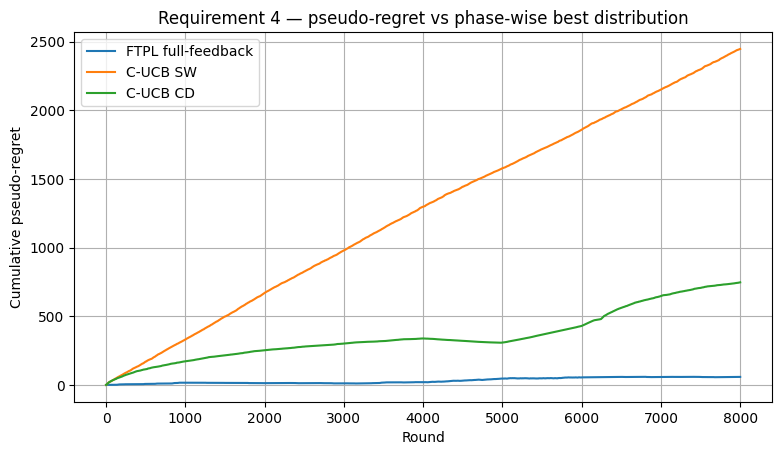

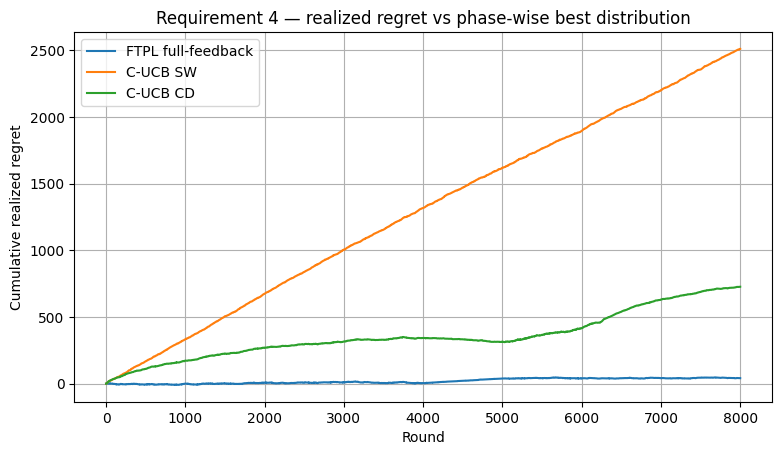

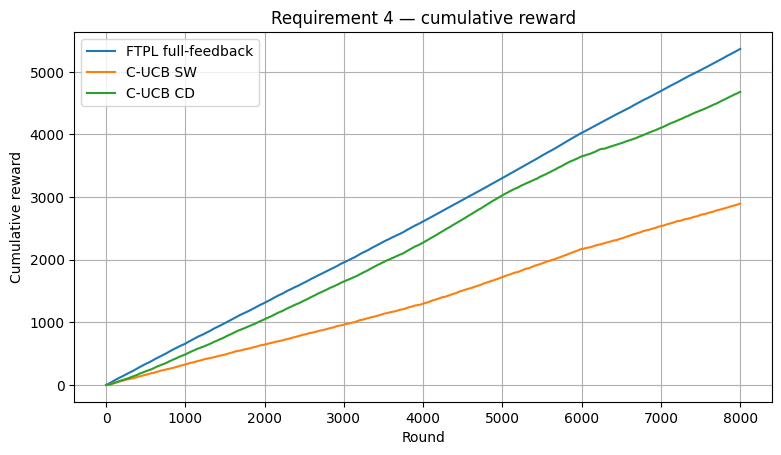

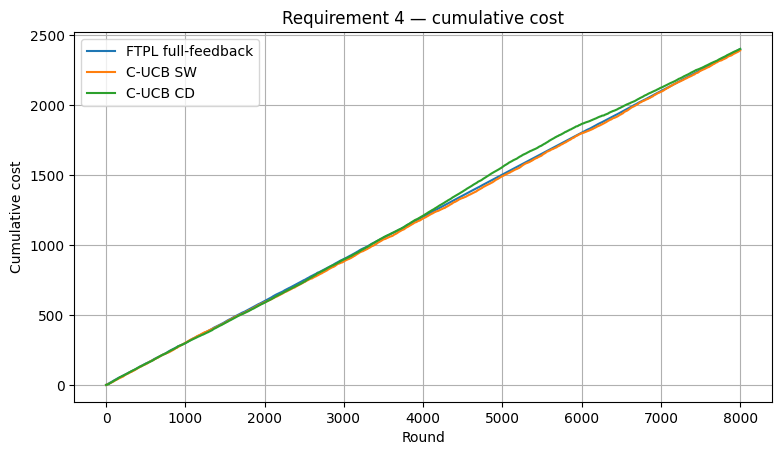

In [63]:
plot_comparison(
    results,
    key="pseudo_regret",
    title="Requirement 4 — pseudo-regret vs phase-wise best distribution",
    ylabel="Cumulative pseudo-regret",
)

plot_comparison(
    results,
    key="regret",
    title="Requirement 4 — realized regret vs phase-wise best distribution",
    ylabel="Cumulative realized regret",
)

plot_comparison(
    results,
    key="reward",
    title="Requirement 4 — cumulative reward",
    ylabel="Cumulative reward",
)

plot_comparison(
    results,
    key="cost",
    title="Requirement 4 — cumulative cost",
    ylabel="Cumulative cost",
)

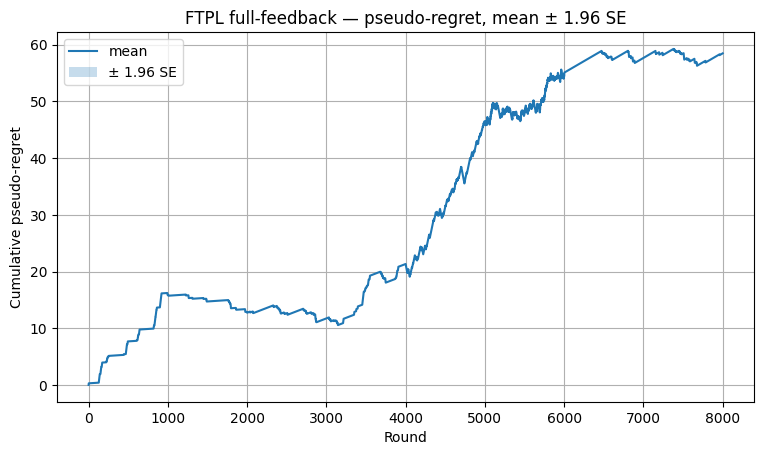

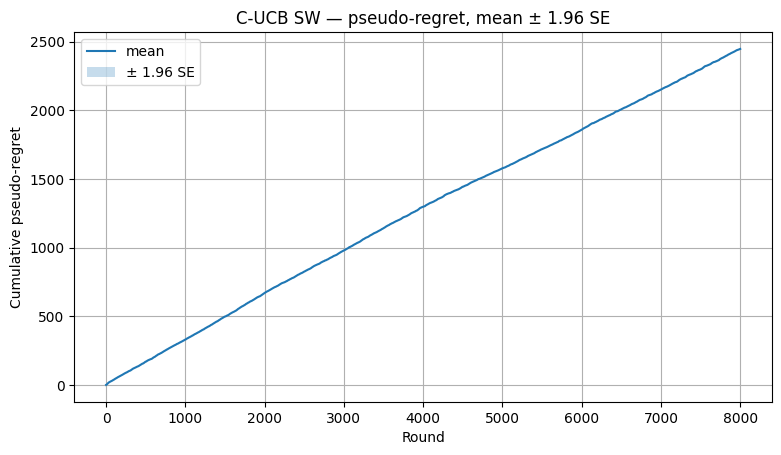

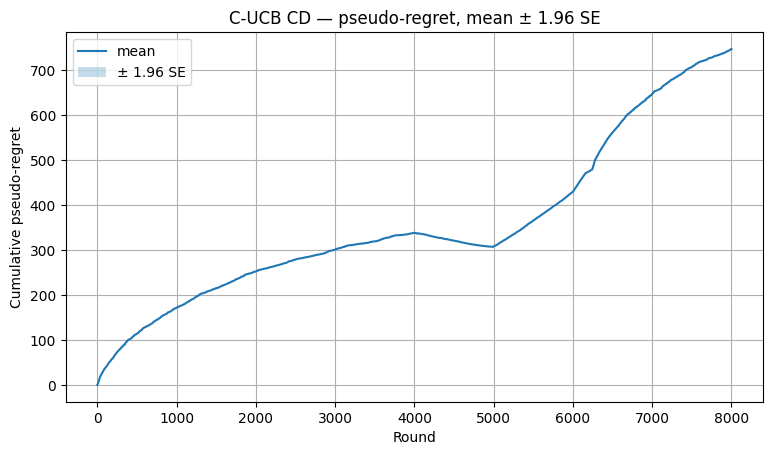

In [64]:
for algo in results:
    plot_mean_ci(
        results[algo],
        key="pseudo_regret",
        title=f"{algo} — pseudo-regret, mean ± 1.96 SE",
        ylabel="Cumulative pseudo-regret",
    )

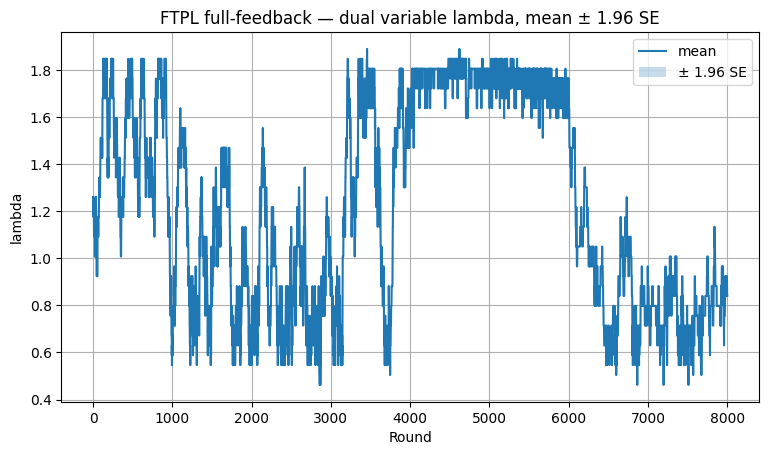

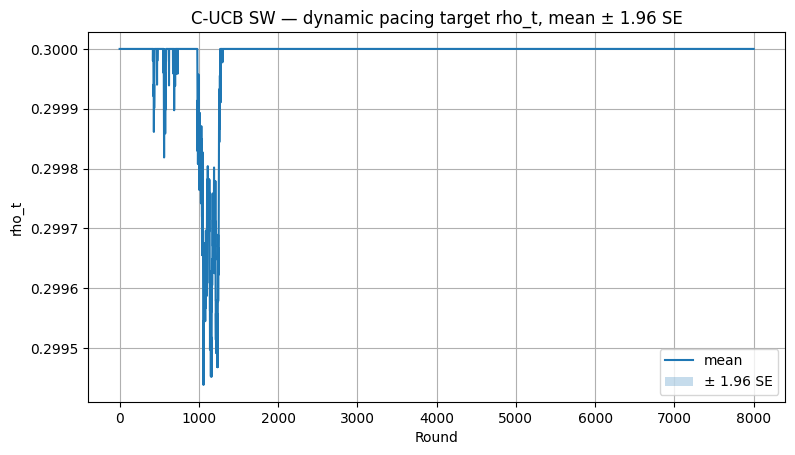

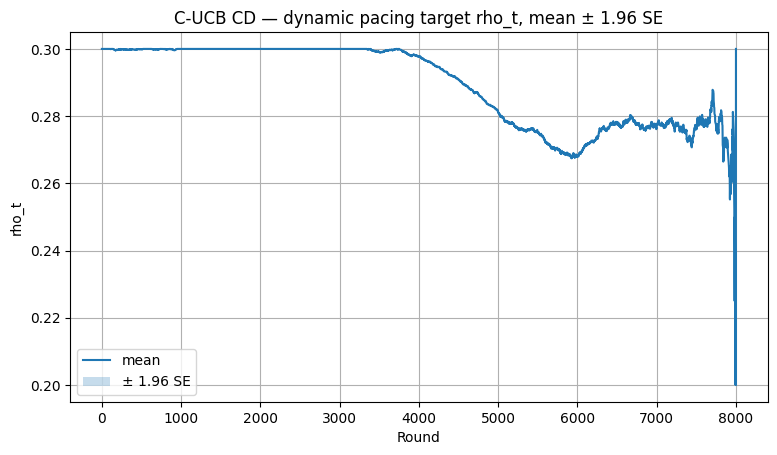

In [65]:
plot_mean_ci(
    results["FTPL full-feedback"],
    key="lambda",
    title="FTPL full-feedback — dual variable lambda, mean ± 1.96 SE",
    ylabel="lambda",
)

plot_mean_ci(
    results["C-UCB SW"],
    key="budget_target",
    title="C-UCB SW — dynamic pacing target rho_t, mean ± 1.96 SE",
    ylabel="rho_t",
)

plot_mean_ci(
    results["C-UCB CD"],
    key="budget_target",
    title="C-UCB CD — dynamic pacing target rho_t, mean ± 1.96 SE",
    ylabel="rho_t",
)

## 13. Change detector diagnostics and feedback sanity check

In [66]:
summarize_detected_changes(results, phases)

,run,true_change_points,detected_changes,n_detected_changes
0,0,"[2000, 4000, 6000]",[6242],1


In [67]:
pd.DataFrame(
    [
        {
            "algorithm": "FTPL full-feedback",
            "feedback_used_by_learner": "full rewards/costs for every feasible action",
            "dynamic_pacing": "No: dual update uses fixed rho = B/T",
            "budget_safety": "hard realized budget guard + worst-case affordable actions",
        },
        {
            "algorithm": "C-UCB SW",
            "feedback_used_by_learner": "semi-bandit selected campaign-bid outcomes only",
            "dynamic_pacing": "Yes: min(B/T, remaining_budget / remaining_rounds)",
            "budget_safety": "hard realized budget guard + budgeted mixture",
        },
        {
            "algorithm": "C-UCB CD",
            "feedback_used_by_learner": "semi-bandit selected campaign-bid outcomes only",
            "dynamic_pacing": "Yes: min(B/T, remaining_budget / remaining_rounds)",
            "budget_safety": "hard realized budget guard + budgeted mixture",
        },
    ]
)

,algorithm,feedback_used_by_learner,dynamic_pacing,budget_safety
0,FTPL full-feedback,full rewards/costs for every feasible action,No: dual update uses fixed rho = B/T,hard realized budget guard + worst-case afford...
1,C-UCB SW,semi-bandit selected campaign-bid outcomes only,"Yes: min(B/T, remaining_budget / remaining_rou...",hard realized budget guard + budgeted mixture
2,C-UCB CD,semi-bandit selected campaign-bid outcomes only,"Yes: min(B/T, remaining_budget / remaining_rou...",hard realized budget guard + budgeted mixture


## 14. Quick tuning notes

- If **C-UCB CD spends too fast**, increase `alpha_cost`, increase the detector `cooldown`, or reduce the change-detection sensitivity by increasing `threshold`. The pacing is already active through `rho_t`.
- If **C-UCB SW adapts too slowly**, reduce `window`; if it is too noisy, increase `window`.
- If **FTPL spends too fast**, increase `lambda_init` or `eta_dual`. This is not dynamic pacing because the update still uses fixed `rho = B/T`.
- If **FTPL under-spends**, decrease `lambda_init` or `eta_dual` slightly, or increase `perturb_scale`.